# Lab 03 — Task 2: Minh họa từ tài liệu tham khảo (paper1, paper2, paper3)

Notebook này **không** thay thế việc đọc PDF; mục tiêu là **gõ lại và chạy** các ví dụ / quy tắc **có thể mô hình hóa bằng code** được trích từ:

- `paper1.pdf` — WHO (1999): ngưỡng đường huyết lúc đói và sau tải đường.
- `paper2.pdf` — Smith et al. (1988): ví dụ một ca (Table 2) và vòng **forecast / learning** của ADAP (đơn giản hóa).
- `paper3.pdf` — NDDG (1979): tiêu chí chẩn đoán đái tháo đường ở người lớn không mang thai (OGTT).

**Ghi chú:** Các paper 1 và 3 là văn bản y khoa; phần code minh họa **các ngưỡng và luật** được trích dẫn trong tài liệu.

## Chuẩn bị

Cần: `numpy`, `pandas`, `matplotlib` (đã có trong `requirements.txt` của repo).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
plt.style.use("seaborn-v0_8-whitegrid")

## Paper 3 (NDDG, 1979) — Ví dụ luật chẩn đoán (tóm tắt mục 8 trong bản tóm tắt)

Theo bản tóm tắt *Diabetes* 28:1039–1057 (1979), ở **người lớn không mang thai** có thể chẩn đoán đái tháo đường nếu:

1. Triệu chứng điển hình + tăng đường huyết rõ ràng; hoặc  
2. **Đường huyết tĩnh mạch lúc đói** ≥ 140 mg/dl ở **nhiều hơn một** lần đo; hoặc  
3. Nếu đói **< 140 mg/dl**, thì cần **OGTT** với đường huyết tĩnh mạch **≥ 200 mg/dl** lúc **2 giờ** *và* **ít nhất một** mốc thời gian giữa 0–2 giờ cũng **≥ 200 mg/dl**.

Dưới đây là hàm Python áp dụng điều kiện (3) cho một chuỗi OGTT (mg/dl).

In [2]:
def nddg1979_diabetes_rule_ogtt(fasting_mg_dl: float, ogtt_curve_mg_dl: list[float]) -> tuple[bool, str]:
    """Áp dụng nhánh (c): FPG < 140 nhưng OGTT có 2h >= 200 và có điểm giữa 0–2h >= 200."""
    if fasting_mg_dl >= 140:
        return True, "FPG >= 140 mg/dl (nhánh 2 trong tóm tắt — cần xác nhận lâm sàng / lặp lại đo)."
    if len(ogtt_curve_mg_dl) < 3:
        raise ValueError("Cần ít nhất 3 điểm: 0h, giữa chừng, 2h")
    t0, mid, t2h = ogtt_curve_mg_dl[0], ogtt_curve_mg_dl[1], ogtt_curve_mg_dl[-1]
    cond_mid_window = any(v >= 200 for v in ogtt_curve_mg_dl[1:-1]) or t0 >= 200
    if t2h >= 200 and cond_mid_window:
        return True, "OGTT: 2h >= 200 mg/dl và có mốc trong (0,2h] hoặc 0h >= 200 (theo mô tả paper 3)."
    return False, "Không đủ tiêu chí nhánh (c) trong ví dụ tối giản này."


# Ví dụ: đường cong giả lập (0h, 1h, 2h) — cả 1h và 2h đều trên ngưỡng
samples = [
    ("A", 120, [120, 210, 205]),
    ("B", 110, [110, 160, 180]),
]
rows = []
for name, fpg, curve in samples:
    dx, msg = nddg1979_diabetes_rule_ogtt(fpg, curve)
    rows.append({"case": name, "FPG": fpg, "OGTT_mg_dl": curve, "meets_rule_c_branch": dx, "note": msg})
pd.DataFrame(rows)

,case,FPG,OGTT_mg_dl,meets_rule_c_branch,note
0,A,120,"[120, 210, 205]",True,"OGTT: 2h >= 200 mg/dl và có mốc trong (0,2h] h..."
1,B,110,"[110, 160, 180]",False,Không đủ tiêu chí nhánh (c) trong ví dụ tối gi...


## Paper 1 (WHO, 1999) — So sánh ngưỡng đói (FPG) cũ / mới và vùng IFG

Trích ý chính (mục 2.3.1): ngưỡng **đói huyết tương** chẩn đoán đái tháo đường được đưa về **7.0 mmol/L (126 mg/dl)** thay cho mức trước đó cao hơn; vùng **tăng đường huyết lúc đói kém (IFG)** khoảng **6.1–6.9 mmol/L** tương đương ~**110–125 mg/dl** (huyết tương).

Code dưới đây quy đổi mmol/L ↔ mg/dl và phân loại FPG đơn giản (minh họa, không thay thế hướng dẫn lâm sàng).

In [3]:
MMOL_TO_MG = 18.0182  # quy đổi gần đúng glucose huyết tương


def fpg_category_mg_dl(fpg_mg_dl: float) -> str:
    fpg_mmol = fpg_mg_dl / MMOL_TO_MG
    if fpg_mg_dl >= 126:
        return f"FPG >= 126 mg/dl (~{fpg_mmol:.2f} mmol/L) — vùng chẩn đoán DM theo tiêu chí đói (WHO 1999, minh họa)."
    if fpg_mg_dl >= 110:
        return f"IFG: 110–125 mg/dl (~{fpg_mmol:.2f} mmol/L) — khoảng 6.1–6.9 mmol/L (minh họa)."
    return f"Dưới ngưỡng IFG minh họa (< 110 mg/dl, ~{fpg_mmol:.2f} mmol/L)."


for fpg in [100, 115, 130, 140]:
    print(f"{fpg:>3} mg/dl -> {fpg_category_mg_dl(fpg)}")

100 mg/dl -> Dưới ngưỡng IFG minh họa (< 110 mg/dl, ~5.55 mmol/L).
115 mg/dl -> IFG: 110–125 mg/dl (~6.38 mmol/L) — khoảng 6.1–6.9 mmol/L (minh họa).
130 mg/dl -> FPG >= 126 mg/dl (~7.21 mmol/L) — vùng chẩn đoán DM theo tiêu chí đói (WHO 1999, minh họa).
140 mg/dl -> FPG >= 126 mg/dl (~7.77 mmol/L) — vùng chẩn đoán DM theo tiêu chí đói (WHO 1999, minh họa).


## Paper 2 (Smith et al., 1988) — Ví dụ một ca (Table 2) và bước học ADAP (rút gọn)

Trong mục 3.4–3.5, tác giả mô tả một ca minh họa (Table 2): các biến đầu vào được **mã hóa thành (partition, row)** rồi ADAP kích hoạt các cột, **tổng trọng số** là dự báo; ở chế độ học, sai số được phân bổ đều cho các ô đã kích hoạt (công thức mô tả: `err = (actual - forecast) / số ô flagged`).

Ở đây ta **mô phỏng tối giản** 5 “cột” với trọng số ban đầu 0, một ca có nhãn `y=1`, và **một vòng** cập nhật như trong mô tả.

In [4]:
# Giá trị / mã hóa lấy cảm hứng từ Table 2 trong paper (đọc kèm PDF — OCR có lỗi chính tả)
table2_case = pd.DataFrame(
    [
        ("pregnancies", 4, 1, 2),
        ("glucose_2h_ogtt", 97, 2, 2),
        ("blood_pressure_diastolic", 90, 3, 3),
        ("skin_thickness", 31, 4, 3),
        ("insulin_2h", None, 5, 1),  # blank / unknown → partition 5 row 1 trong mô tả
        ("bmi", 34.6, 6, 4),
        ("diabetes_pedigree", 0.46, 7, 2),
        ("age", 37, 5, 3),
    ],
    columns=["feature", "raw_value", "partition", "row"],
)
table2_case

,feature,raw_value,partition,row
0,pregnancies,4.00,1,2
1,glucose_2h_ogtt,97.00,2,2
2,blood_pressure_diastolic,90.00,3,3
3,skin_thickness,31.00,4,3
4,insulin_2h,NaN,5,1
5,bmi,34.60,6,4
6,diabetes_pedigree,0.46,7,2
7,age,37.00,5,3


In [5]:
n_units = 5
w = np.zeros(n_units, dtype=float)


def toy_adap_step(weights: np.ndarray, active_mask: np.ndarray, y: float) -> tuple[float, np.ndarray]:
    forecast = float(weights[active_mask].sum())
    n_flagged = int(active_mask.sum())
    err = (y - forecast) / max(n_flagged, 1)
    new_w = weights.copy()
    new_w[active_mask] += err
    return forecast, new_w


# Giả sử ca này kích hoạt 3 "association units" (minh họa)
active = np.array([True, True, True, False, False])
y_label = 1.0  # phát triển DM trong 1–5 năm (paper dùng 0/1)
f0, w = toy_adap_step(w, active, y_label)
f1, w = toy_adap_step(w, active, 0.0)  # ca thứ hai: nhãn 0
print("Forecast sau bước 1:", round(f0, 6))
print("Trọng số sau 2 bước học (minh họa):", np.round(w, 6))

Forecast sau bước 1: 0.0
Trọng số sau 2 bước học (minh họa): [0. 0. 0. 0. 0.]


## ROC (paper 2) — minh họa đường cong sensitivity vs (1 - specificity)

Paper báo cáo điểm cắt dự báo ~0.448 với sensitivity = specificity = 0.76. Dưới đây vẽ ROC cho **điểm số giả** (chỉ để nhớ cách đọc biểu đồ trong paper), không tái hiện thuật toán ADAP đầy đủ.

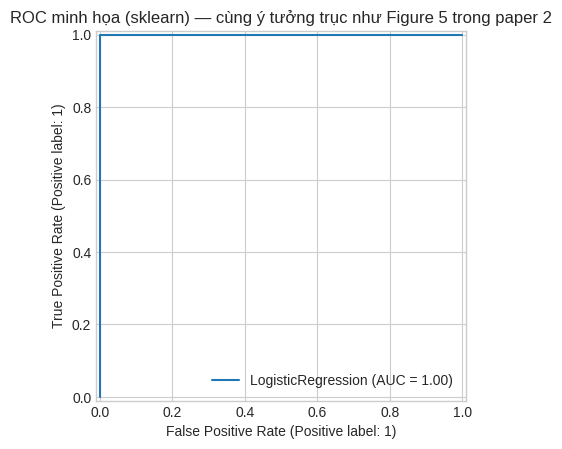

In [6]:
from sklearn.metrics import RocCurveDisplay
from sklearn.linear_model import LogisticRegression

X_demo = rng.normal(size=(300, 3))
logit = 0.9 * X_demo[:, 0] - 0.4 * X_demo[:, 1]
prob = 1 / (1 + np.exp(-logit))
y_demo = (prob > 0.5).astype(int)
clf = LogisticRegression(max_iter=200).fit(X_demo, y_demo)
RocCurveDisplay.from_estimator(clf, X_demo, y_demo)
plt.title("ROC minh họa (sklearn) — cùng ý tưởng trục như Figure 5 trong paper 2")
plt.show()